# Anomaly Detection Notebook

## 1. Importing Libraries and Loading Data
In this section, the notebook imports all necessary libraries including pandas, NumPy, matplotlib, and the IsolationForest algorithm from scikit-learn. It then loads the dataset from a CSV file and displays a preview to ensure that the data has been loaded successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load the dataset
file_path = "Kelloe mains Harvest_2023(2).csv"
df = pd.read_csv(file_path)

# Preview the dataset
print("Dataset preview:")
print(df.head())


Dataset preview:
    Clients         Farms     Fields               Machine Name  \
0  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
1  Mcdonald  kelloe mains     birsby  8400i - SK19 LFR (R Wood)   
2  Mcdonald  kelloe mains     birsby  8400i - SK16 GTY (R Wood)   
3  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
4  Mcdonald  kelloe mains  Craig mae  8500i - SL22 SYY (R Wood)   

           Equipment         Operators Varieties  \
0  1Z08500YANU622386  Unknown Operator   1ST Cut   
1  1Z08400YEKU619149  Unknown Operator   2ND CUT   
2  1Z08400YJGR515326  Unknown Operator   3RD CUT   
3  1Z08500YANU622386  Unknown Operator   4TH CUT   
4  1Z08500YANU622386  Unknown Operator   1ST Cut   

                                            Work     Crop Type  \
0  Forage Harvesting Grass Forage - May 17, 2023  Grass Forage   
1  Forage Harvesting Grass Forage - Jun 13, 2023  Grass Forage   
2  Forage Harvesting Grass Forage - Jul 20, 2023  Grass Forage   
3  

## 2. Data Preprocessing for Anomaly Detection
This section focuses on preparing the data for anomaly detection by:
- Converting key features (such as "Area Harvested", "Moisture", "Dry Yield", "Speed", "Total Fuel", and "Fuel Efficiency") into numeric values, while handling non-numeric placeholders.
- Dropping rows with missing values in the selected features.
These steps help ensure the data is clean and ready for further analysis.


In [2]:
# Define a helper function to convert columns to numeric values (handling placeholders like '---')
def to_numeric(col):
    return pd.to_numeric(col.replace('---', np.nan), errors='coerce')

# Select key numeric features for anomaly detection
features = ["Area Harvested", "Moisture", "Dry Yield", "Speed", "Total Fuel", "Fuel Efficiency"]

# Convert the selected columns to numeric
for col in features:
    df[col] = to_numeric(df[col])

# Drop rows with missing values in the selected features
df_clean = df.dropna(subset=features)
print("Cleaned data shape:", df_clean.shape)


Cleaned data shape: (69, 65)


## 3. Exploratory Data Analysis (EDA) - Visualizing Feature Distributions
Here, boxplots are generated for each selected feature. This visual analysis allows you to inspect the distribution of the data and identify any potential outliers that may affect the anomaly detection process.


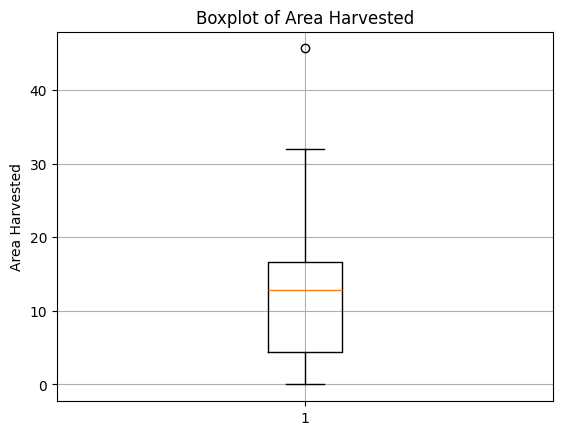

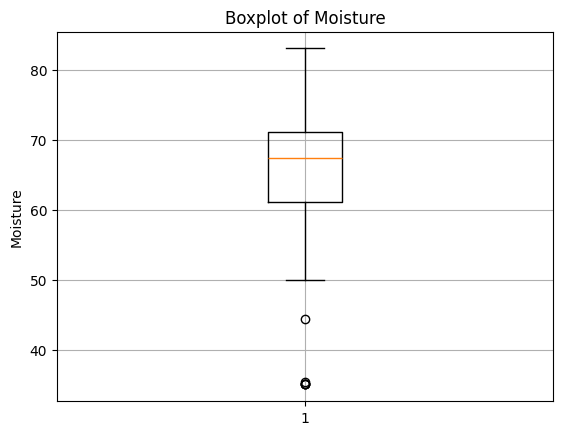

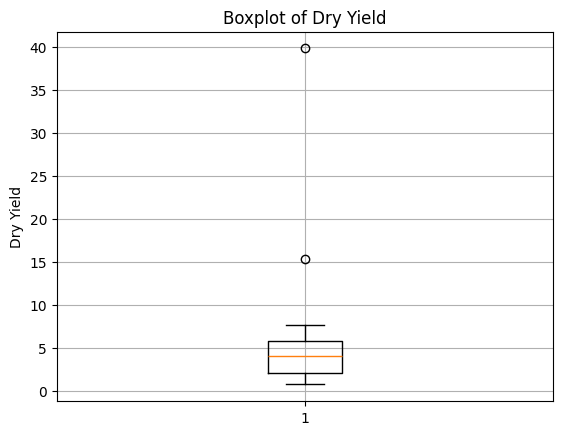

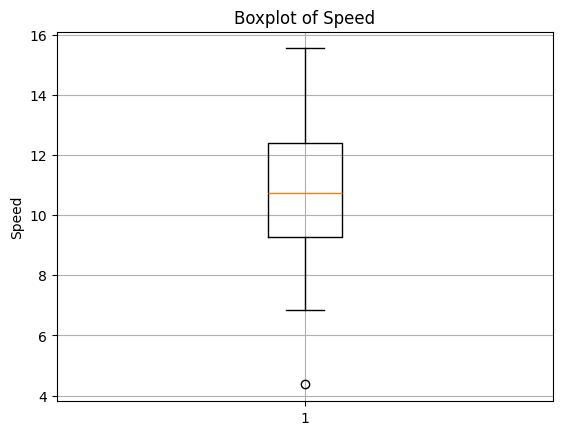

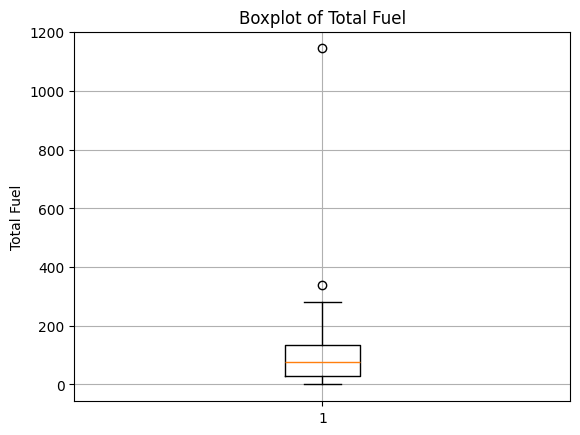

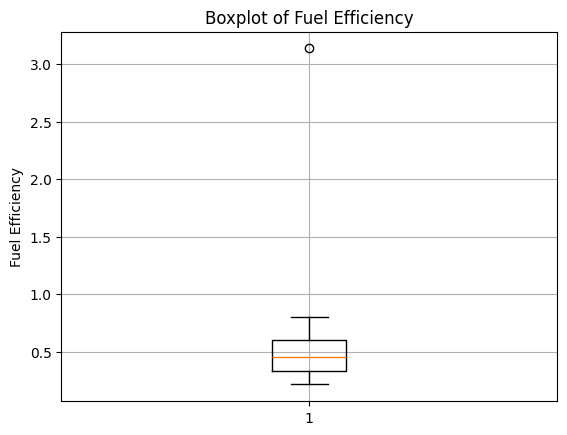

In [3]:
# Plot boxplots for each selected feature to inspect data distribution and potential outliers
for feature in features:
    plt.figure()
    plt.boxplot(df_clean[feature])
    plt.title(f"Boxplot of {feature}")
    plt.ylabel(feature)
    plt.grid(True)
    plt.show()


## 4. Applying Isolation Forest for Anomaly Detection
In this part, the Isolation Forest algorithm is applied to the preprocessed data. The model is configured with an appropriate contamination rate to detect anomalies within the dataset. Each data point is labeled as either normal (1) or an anomaly (-1).


In [4]:
# Use Isolation Forest to identify anomalies in the selected features
X = df_clean[features]
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Adjust contamination as needed
df_clean['anomaly'] = iso_forest.fit_predict(X)

# Print count of detected anomalies (-1 indicates an anomaly, 1 indicates normal)
print("Anomaly value counts:")
print(df_clean['anomaly'].value_counts())


Anomaly value counts:
anomaly
 1    65
-1     4
Name: count, dtype: int64


## 5. Visualizing Detected Anomalies
This section separates the normal data points from those flagged as anomalies. A scatter plot (for instance, plotting "Dry Yield" versus "Fuel Efficiency") is created to visually distinguish between normal observations and outliers, with anomalies highlighted for clarity.


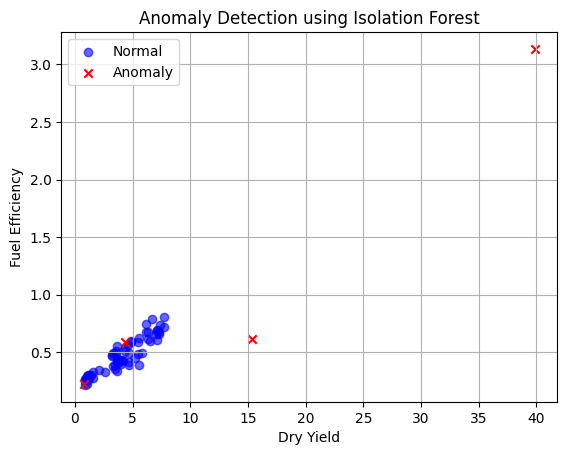

In [5]:
# Separate normal data from anomalies
normal_data = df_clean[df_clean['anomaly'] == 1]
anomalies = df_clean[df_clean['anomaly'] == -1]

# Create a scatter plot comparing "Dry Yield" vs "Fuel Efficiency", highlighting anomalies
plt.figure()
plt.scatter(normal_data["Dry Yield"], normal_data["Fuel Efficiency"], c='blue', label='Normal', alpha=0.6)
plt.scatter(anomalies["Dry Yield"], anomalies["Fuel Efficiency"], c='red', label='Anomaly', marker='x')
plt.xlabel("Dry Yield")
plt.ylabel("Fuel Efficiency")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()
plt.grid(True)
plt.show()


## 6. Reviewing Anomalies
Finally, the notebook displays the details of the detected anomalies. This allows for further investigation into the unusual data points, which might indicate issues in the data collection process or represent truly exceptional events.

In [6]:
# Display the anomalies for further investigation
print("Anomalies detected:")
print(anomalies)


Anomalies detected:
     Clients         Farms        Fields               Machine Name  \
40  Mcdonald  kelloe mains  Robins croft  8500i - SL22 SYY (R Wood)   
42  Mcdonald  kelloe mains  Robins croft  8400i - SK19 LFR (R Wood)   
44  Mcdonald  kelloe mains  Robins croft  8500i - SL22 SYY (R Wood)   
68  Mcdonald  kelloe mains     Whitemire  8400i - SK19 LFR (R Wood)   

            Equipment         Operators Varieties  \
40  1Z08500YANU622386  Unknown Operator   4TH CUT   
42  1Z08400YEKU619149  Unknown Operator   2ND CUT   
44  1Z08500YANU622386  Unknown Operator   4TH CUT   
68  1Z08400YEKU619149  Unknown Operator       RYE   

                                               Work       Crop Type  \
40    Forage Harvesting Grass Forage - May 19, 2023    Grass Forage   
42    Forage Harvesting Grass Forage - Jun 14, 2023    Grass Forage   
44    Forage Harvesting Grass Forage - Oct 11, 2023    Grass Forage   
68  Forage Harvesting Boot stage WCS - Jul 11, 2023  Boot stage WCS   

  